# TPC Dongwi $^{239}$Pu(n,f)/$^{235}$U(n,f) cs data preparation for GMA (Data release: LA-UR-25-32229)

## Update 3/30/2026-4/15/2026:
- The Standards decided to treat fissionTPC data as shape.
- I think some part of the background uncertainty should be energy-dependent. 

In [5]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
homedir = os.getcwd() +'/'

In [9]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [11]:
import Class_nfcs as Cnf
reload(Cnf)

<module 'Class_nfcs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs.py'>

Text(0, 0.5, 'Relative Uncertainty (%)')

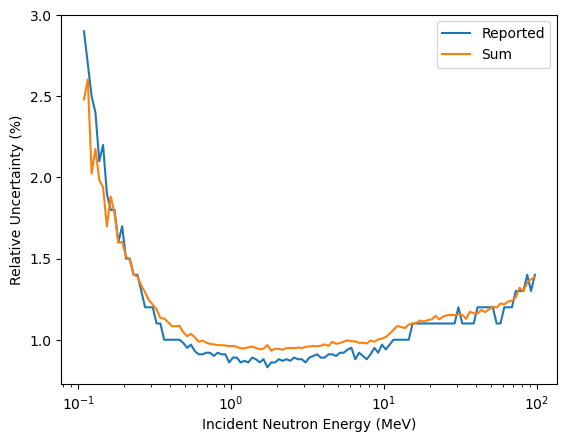

In [17]:
# update 4/15/2026 ------------------------------
forStandards = True

datafile = homedir+'Dongwi.dat'
alldata  = loadtxt(datafile,skiprows=1)
Einc = 0.5*alldata[:,0]+0.5*alldata[:,1]

count = 0
for index in arange(0,len(Einc)):
    count = count + 1
    if Einc[index] > 20.0:
        break

if forStandards:
    end = len(Einc)+1
else:
    end = count 
# -------------------------------------------------

datafile = homedir+'Dongwi.dat'
alldata  = loadtxt(datafile,skiprows=1)
Einc = 0.5*alldata[:end,0]+0.5*alldata[:end,1] # The incident neutron energy is supplied
# in the form of a lower and upper bin edge. ARIADNE as well as GMA cannot deal 
# with that. Instead, an Einc per each data value needs to be supplied. I take
# the mid-point of the energy bin as this one-point energy. Luke oked that for Snyder data.
# checked that all partial uncertainties and Data are on the same grid.
# update 4/15/2026 ------------------------------
Einclow  = alldata[:end,0] # MeV
Einchigh = alldata[:end,1] # MeV
edgesE      = zeros(len(Einc) + 1,dtype=float)
edgesE[:-1] = Einclow
edgesE[-1]  = Einchigh[-1]
# For energy resolution.
# -------------------------------------------------

Ersl = alldata[:end,2]*100.0/(2.355*Einc) # energy resolution is given in MeV
# for FWHM. I convert it to % units of 1-sigma.

Data = alldata[:end,3] # absolute Pu-239(n,f)/U-235(n,f), the data are normalized with
# their own normalization (sample mass and non-uniformity of beam/ sample and 
# beam overlap). However, they are systematically 2% off.

Totunc = alldata[:end,4] # The total uncertainties are given.
# Counter-check if the partial uncertainties add up.


normunc_countstat_eff_spectrumfit = sqrt(0.075**2.0+0.105**2.0+0.202**2.0+0.061**2.0+\
                                            0.06**2.0+0.006**2.0+0.023**2.0)
normunc_massspec = sqrt(0.657**2.0+0.005**2.0)
normunc_halflife = sqrt(0.136**2.0+0.046**2.0)


# update 4/15/2026 ------------------------------
thermalbckgrd = ones(len(Einc),dtype=float)*0.1
for index in arange(0,len(Einc)):
    thermalbckgrd[index] = 0.1 + 0.1 * (max(Einc)-Einc[index])/(max(Einc)-min(Einc))


normunc_spacecharge = 0.85 # will not be used

normunc = sqrt(normunc_countstat_eff_spectrumfit**2.0+normunc_massspec**2.0+normunc_halflife**2.0+\
               normunc_spacecharge**2.0) # will not be used
# -------------------------------------------------

statunc = alldata[:end,5] # %, The statistical uncertainty is explicitly supplied
# by the experimentalist. 


deteffunc1 = alldata[:end,6] # %, The first detector efficiency uncertainty is the
# "variational" unc. which accounts for the variation in the PID cuts.
# The correlation matrix is varying around slightly positive and slightly 
# negative from 0.3-200 MeV. Below it is more positive. It will be a
# challenge to approximate that. 
# It is interesting to note that these variational (PSD cut) correlations 
# are closer to zero above 0.3 MeV, while the U-8/U-5 correlations for 
# this uncertainty source are more pronounced positive above 0.3 MeV.

background = alldata[:end,7] # %, The backrground uncertainty accounts for background
# correction uncertainties related to the wrap-around background. Background due to
# fission fragment recoils and a-particles is zero because they are clearly identified
# by PID cuts. The unc. in the variation of the PID cut is the variational unc. 
# The correlation matrix provided by R. Casperson is best approximated with a
# Gaussian anti-correlation with a turning point
# at Einc = 1.4545 MeV and a damping term of 1 in a visual comparison with
# that option of ARIADNE and the partial correlation matrix provided by R.
# Casperson.
# The shape wrap-around correlations of Pu-9/U-5 are similar to those of U-8/U-5, 
# although they are less strongly positive. This is curious in as far as I would 
# expect a similar wrap-around effect and correction for both measurements given 
# that you took them at the same facility? In the same vein, your wrap-around
# uncertainties seem smaller at high Eout than those in the PRC by Robert?

deteffunc2 = alldata[:end,8] #%, The second efficiency uncertainty accounts for uncertainties
# in the efficiency model such as in the SRIM stopping power assumption, FY unc., etc.,
# The correlation matrix is on average diagonal in a visual comparison with the partial
# correlation matrix provided by L. Snyder in private communication. Correlations 
# to other measurements could arise because of common usage of SRIM. However, the correlation
# matrix is diagonal to begin with. Even if it was not diagonal, only low Einc would be
# affected by the cross-correlations according to a discussion with R. Casperson.

impurity = alldata[:end,9] # %, The impurity uncertainty accounts for contaminations in
# the sample. The correlation matrix for U-5/U-8 was fully correlated in as provided 
# by Robert, while this one is closer to average correlations of 0.3. Is that because 
# you know the contamination level and nuclear (structure) data much better than the 
# alpha-counts??

overlap = alldata[:end,10] # %, beam-overlap uncertainties are nearly diagonal. My first 
# instinct would have been that they are fully correlated as it applies to the 
# whole measurement, but as Luke says in his journal article, the beam 
# overlap is Einc-dependent due to the beam. Is it also diagonal because 
# he effectively measures beam overlap by identifying alphas.

attenuation = alldata[:end,11] # %, attenuation uncertainties are explicitly
# given after asking for them. They are diagonal as they only encompass
# MC statistics uncertainties.

Totunc2= sqrt(overlap*overlap+impurity*impurity+deteffunc2*deteffunc2+\
deteffunc1*deteffunc1+statunc*statunc+background*background+attenuation*attenuation)#+alldata[:,8]*alldata[:,8])

plt.semilogx(Einc,Totunc)
plt.semilogx(Einc,sqrt(Totunc2**2.0+0.79*0.79))
plt.legend(['Reported','Sum'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [19]:
features = {"Author": ["D.H. Dongwi", "L. Snyder", "V. Aguilar", "N. Androski", "M. Anastasiou", "N.S. Bowden", "A. Chemey", "T. Classen", "J.E. Fuzaro Alencar", "U. Greife", "M. Haseman", "L.D. Isenhower", "J.L. Klay", "W. Loveland", "M.P. Mendenhall", "M. Monterial", "C. Prokop", "M. Silveira", "T.S. Watson", "L. Yao"],
"Year": "2025",
'Absolute':'n',\
"Facility": ['LINAC','SPALL','1USALAS'],
"Institute": ["1USALAS", "1USALRL", "1USAORU", "1USACSM"],
"Isotope": "Pu-239",
"Quantity": "cs", 'reaction': 'n,f',\
"MeasurementType": "Clean ratio",
"ConcernEXFOR": "None",
"ConcernPARADIGM": ["Wraparound","Overlap"],
"ConcernPARADIGM_text": ["Wraparound correction applied but might miss thermal background.","Beam overlap correction applied, but space-charge correction could not be verieifed within 0.85% at LANL and LLNL leading to that span-width of potnetial differences in cs."],
"BackgroundCorrected": "partial",
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "partial",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "y",
"MultipleScatteringSampleBackingCorrected": "y",
"MultipleScatteringSurroundingCorrected": "y",
"AttenuationSampleBackingCorrected": "y",
"AttenuationSurroundingCorrected": "y",
"FissionDetectionEfficiencyCorrected": "y",
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "N/A",
"DeadtimeCorrected": "N/A",
"AngularDistributionFissionFragmentsCorrected": "y",
"ImpuritiesCorrected": "y",
"CorrelatedData": "14721002",
"EXFORnumber": "14851002",
"Accepted": "y",
"MissingCorrections": ["ThermalBackground","RandomCoincidenceBackground"],
"FissionDetector": {
"Type": "MICROMEGAS TPC (fissionTPC)",
"ParticleDetected": "FF",
"Efficiency": "unknown",
"EfficiencyMethod": ["TPC track-based selection and normalization"],
"FFAbsorptionAngularDistributionMethod": "Calculated",
"AngularAcceptaneofFF": "unknown",
"Gas": {
"Type": "Ar + 5% isobutane",
"Purity": "high-purity",
"Pressure": "550 torr"
},
"Size": { "geometry": "two-volume TPC, central cathode" },
"NoPhotomultipliers": "N/A",
"Weight": "unknown",
"StructuralMaterial": "unknown",
"ReferenceDetector": ["N/A"]
},
"NeutronDetector": {
"Type": "None (white source + TOF)",
"Number": "N/A",
"ParticleDetected": "N/A",
"Efficiency": "N/A",
"ResponseDeterminationMethod": "N/A",
"EfficiencyDeterminationMethod": "N/A",
"Angle": "N/A",
"TOFLength": { "Value": "90L", "Unit": "flight path label", "Unc": "unknown" },
"trsl": { "Value": "unknown", "Unit": "ns", "Measure": "FWHM" },
"t0Determination": "unknown",
"Gas": { "Type": "N/A", "Purity": "N/A", "Pressure": "N/A" },
"Size": { "geometry": "N/A" },
"NoPhotomultipliers": "N/A",
"Photomultipliers": "N/A",
"Weight": "N/A",
"StructuralMaterial": "N/A",
"ReferenceDetector": "N/A",
"ReferenceReaction": "N/A"
},
"Shielding": { "Material": "unknown", "Size": "unknown", "DistanceFromNeutronDetector": "N/A", "Purpose": "unknown" },
"Sample": {
"Activity": "unknown",
"Activity_unit": "unknown",
"Reused": "unknown",
"Form": "vapor-deposited Pu-239 and U-235 targets on central cathode",
"Mass": "unknown",
"Diameter": "unknown",
"Thickness": "unknown",
"Homogenity": "Pu uniformity ~10% std. dev.; improved over prior electroplated target",
"Contaminants": "minor U and Pu isotopic admixtures per MC-ICP-MS",
"BackingMaterial": "unknown",
"BackingDiameter": "unknown",
"BackingThickness": "unknown",
"DecayDeterminationMethod": "unknown",
"Configuration": "Two actinide deposits on central cathode",
"Fabrication": "vapor-deposited Pu; vapor-deposited U",
"ImpurityDetermination": "MC-ICP-MS"
},
"ShadowBar": { "Used": "unknown", "Material": "unknown", "Size": "unknown", "Size_unit": "unknown", "Material of structure holding it": "unknown" },
"OutgoingEnergyDetermination": "TOF",
"IndividualChannelWidthDetermination": "unknown",
"AverageChannelWidthDetermination": "unknown",
"BackgroundMethods": {
"General": "corrections applied as listed",
"Wraparound": "calculated",
"alpha": "PSD",
"Gamma": "PSD",
"RandomCoincidence": "WrapAround"
},
"MultipleScatteringMethods": { "InSample": "MC", "Surrounding": ["MC"] },
"AttenuationMethods": { "InSample": "MC", "Surrounding": ["MC"] },
"DeadtimeDeterminationMethod": "measured and modeled during normalization analysis",
}



Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/ReferenceData_dict.txt
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'i

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


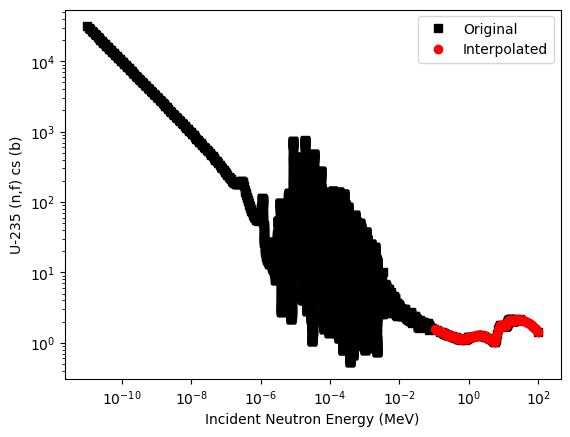

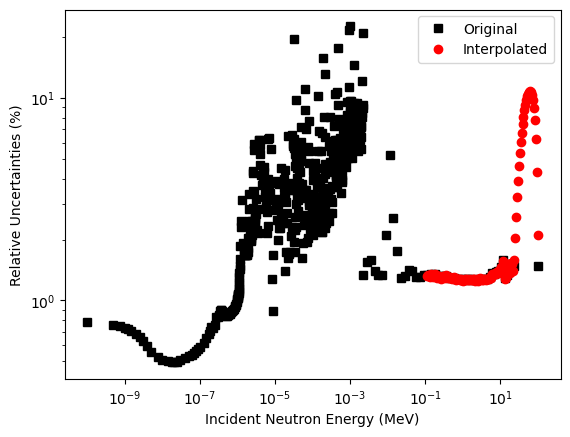

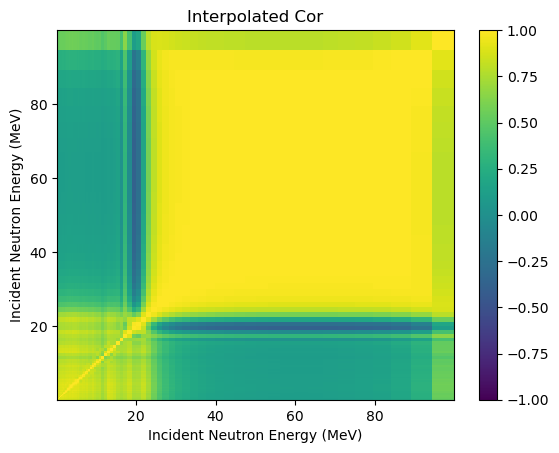

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6002_Pu9U5TPC/DS6002.xml
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6002_Pu9U5TPC/DS6002EUCLID.json
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_6002_Pu9U5TPC/DS6002ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-g

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


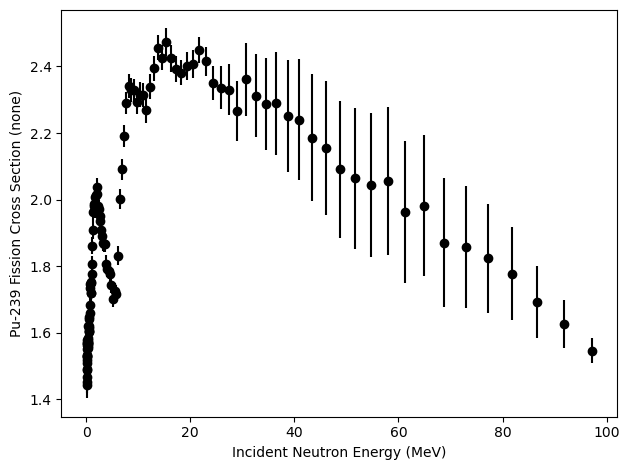

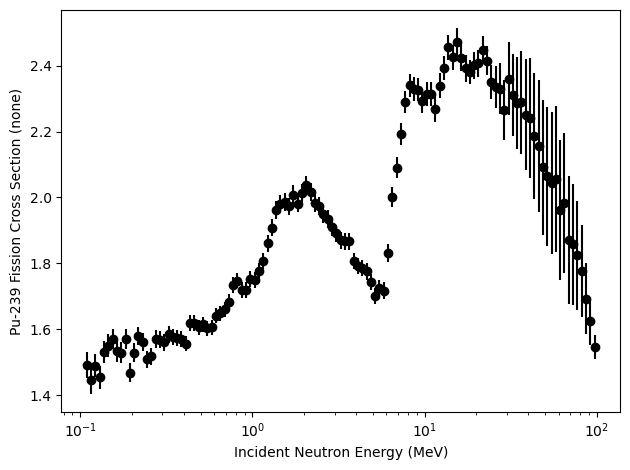

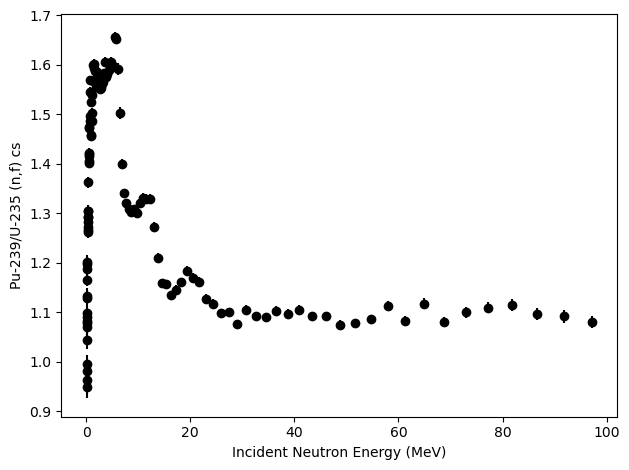

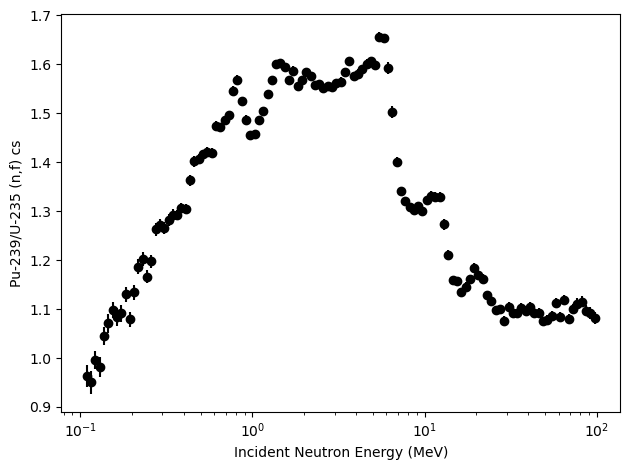

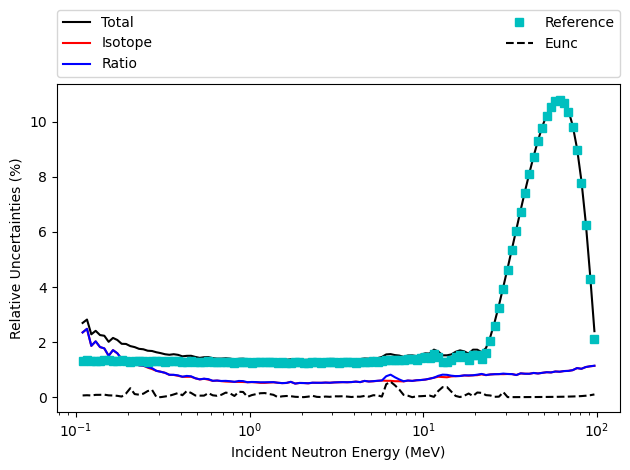

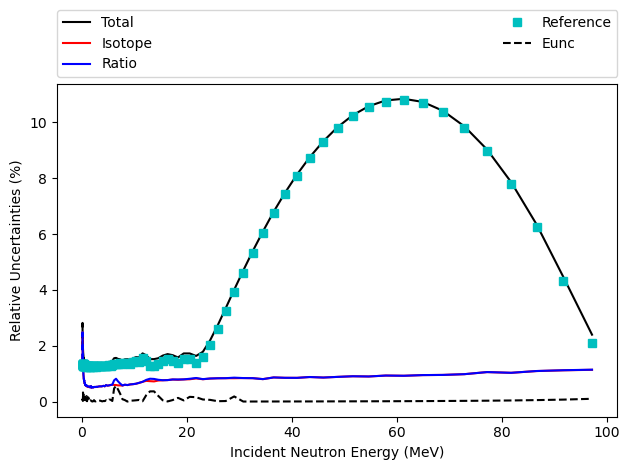

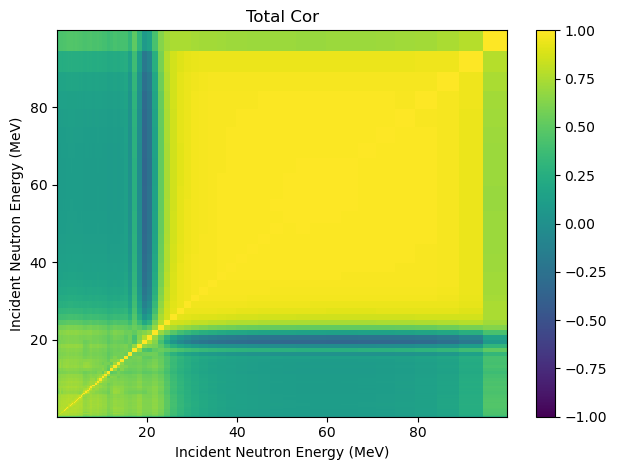

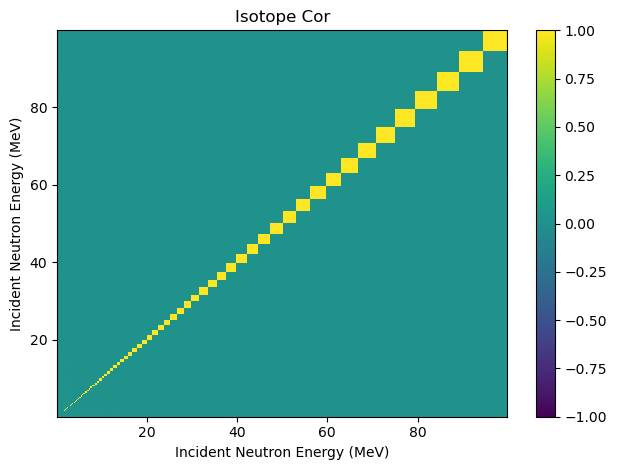

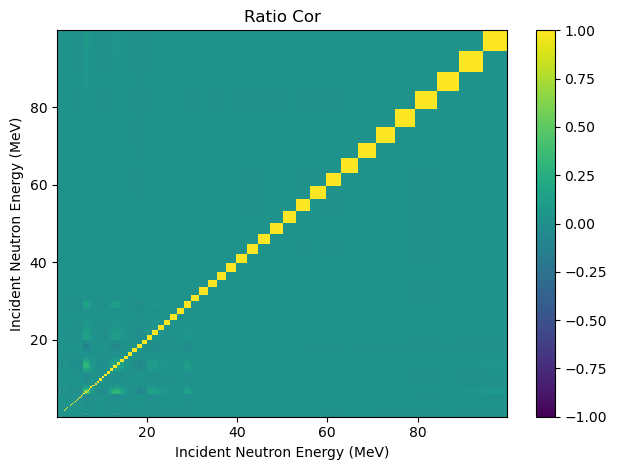

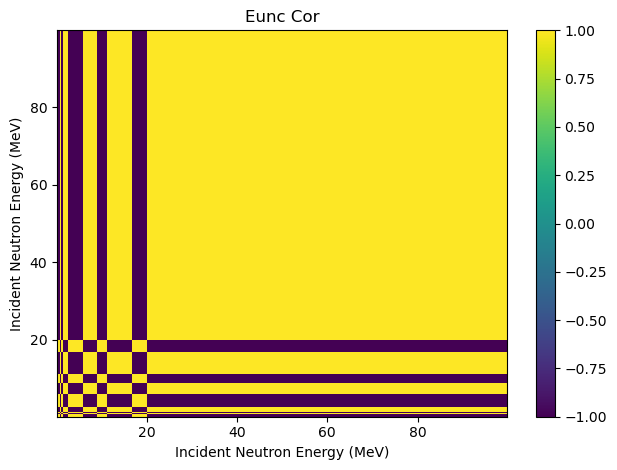

In [21]:
Documentation = """EXFOR No. = 14851002; the data are not yet in GMA, following the current numbering \
	and convention, I would assign D6002; Journal article = Dongwi et al., Nuclear Data Sheets, Vol.202, p.30 (2025). \
	The data used in here are all provided by EXFOR. The incident neutron energy is supplied in the form of a lower and upper bin edge. \
	ARIADNE as well as GMA cannot deal with that. Instead, an Einc per each data value needs to \
 	be supplied. I take the mid-point of the energy bin as this one-point energy. This procedure \
 	was discussed with L. Snyder in private communication and he agreed that this is \
 	acceptable. The data are absolute Pu-239(n,f)/U-235(n,f) data. They were normalized with \
    their own procedure but are systematically off by 2% compared to ENDF/B-VIII.0 \
    which they do not fully trust because of issues in space charge and thermal background that\
    remain unresolved. I added 0.85% and 0.75% normalization unc. for those as they would be constant.\
    The statistical uncertainty is explicitly supplied by the experimentalist and the \
    correlation matrix is assumed to be diagonal. The first detector efficiency uncertainty \
    is the "variational" unc. which accounts for the variation in the PID cuts. The \
    correlation matrix is constant with a factor of 0.15 in a visual comparison with \
    that option of ARIADNE and the partial correlation matrix provided by L. Snyder \
    (not perfect). The background uncertainty accounts for background correction uncertainties \
 	related to the wrap-around background. Background due to fission fragment recoils and alpha-\
	particles is zero because they are clearly identified by PID cuts. The unc. in the variation \
 	of the PID cut is the variational unc. The correlation matrix provided by L. Snyder is \
 	best approximated with a diagonal one in a visual comparison with that option of ARIADNE \
    and the partial correlation matrix provided by L. Snyder. The second efficiency uncertainty \
    accounts for uncertainties in the efficiency model such as in the SRIM stopping power assumption,\
    FY unc., etc., The correlation matrix is on average diagonal in a visual comparison with the partial \
	correlation matrix provided by L. Snyder in private communication. Correlations to other \
 	measurements could arise because of common usage of SRIM. However, the correlation matrix is \
 	diagonal to begin with. Even if it was not diagonal, only low Einc would be correlated due to \
	common usage of SRIM according to a discussion with R. Casperson (U-8/U-5). The impurity uncertainty \
 	accounts for contaminations in the sample. The correlation matrix is correlated with a factor of 0.35 in a \
 	visual comparison with the data provided by L. Snyder. This uncertainty could be \
 	correlated to other measurements due to usage of alpha-counting and related nuclear data. \
	No normalization unc. needs to be accounted for as this is treated as a shape measurement. Attenuation \
	and multiple scattering uncertainties are provided by L. Snyder and are diagonal (MC statistics,\
    only, no nuclear data unc. considered}. The FF angular \
    distribution uncertainty is part of the detector efficiency uncertainty. The energy \
    uncertainty is obtained by accounting for the TOF length unc. and trsl which is provided \
    in the journal article. The dead time uncertainty is zero according to L. Snyder\
    due to improved electronics. The beam-sample-overlap uncertainty is explicitly given \
    and provided by L. Snyder. It is energy-dependent and nearly diagonal, because it \
    was corrected with a measurement. Private communication took place by phone meeting\
    and e-mail exchange in the time-frame from late summer of 2025 to Oct. of\
    2025, L. Snyder was involved in that exchange."""


general_info = {'name': 'DS6002', 'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6002.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

resolution = {'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'energy_resolution': Ersl*Einc*2.355/100.0,
              'energy_resolution_unit': 'MeV'}

einc_unc = {'en_err' : {'enerr_unc': array(Ersl*0.2),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.1','resolution':resolution}


norm_unc = {'value': normunc, 'unit':'%'}

reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VIII.1'}

unc_iso = {'einc_unc': einc_unc,\
           'values':array([statunc,deteffunc1,background,\
                           deteffunc2,impurity,overlap,attenuation]).transpose(),\
           'units':['%','%','%','%','%','%'],\
           'type':['Diagonal','Constant','Gaussian',\
                   'Diagonal','Constant','Diagonal','Diagonal'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,0.15,1.0,1.0,0.35,1.0,1.0]}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "none" }

DS6002_nfcs = Cnf.nfcs_cleanratioshape(general_info,data,unc_iso,reference,features)

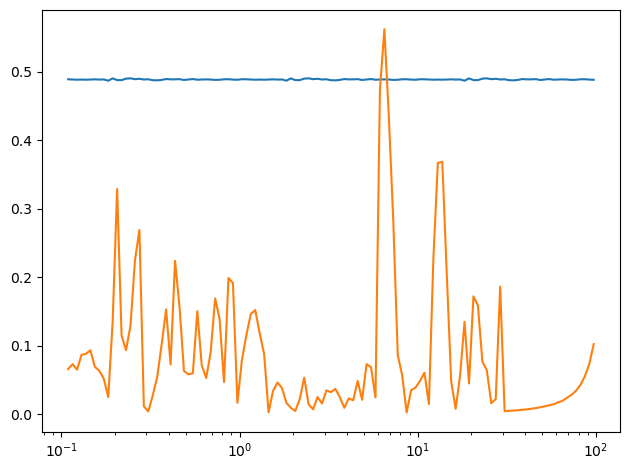

In [23]:
# get energy uncertainties in energy
cscov = DS6002_nfcs.cov_eunc
dim = shape(Einc)[0]
Euncov = zeros([dim,dim],dtype=float)
deriv_nucdata = [1.18603319e+00, 1.22569876e+00, 1.07957194e+00, 1.34014346e+00\
, 1.37067292e+00, 1.40392811e+00, 1.00767001e+00, 8.57569312e-01\
, 6.67553634e-01, 3.15011254e-01, 1.53379208e+00, 3.72046346e+00\
, 1.28291396e+00, 9.93418328e-01, 1.25770376e+00, 2.12450883e+00\
, 2.53218341e+00,- 1.01322858e-01,- 3.29586614e-02, 2.19238029e-01\
, 4.17597750e-01, 7.38131525e-01, 1.05466419e+00, 4.71933511e-01\
, 1.43674413e+00, 9.79310496e-01, 3.72743433e-01, 3.25960230e-01\
, 3.16193995e-01, 7.54835363e-01, 3.48545771e-01, 2.44362262e-01\
, 3.98216028e-01, 7.09919601e-01, 5.69883015e-01,- 1.83240802e-01\
,- 7.15512287e-01,- 6.34923352e-01,- 5.03426089e-02, 2.25435988e-01\
, 3.19794897e-01, 3.88765132e-01, 3.91498278e-01, 2.92133759e-01\
, 2.09066725e-01,- 5.86774683e-03,- 7.12236228e-02,- 9.07872354e-02\
,- 7.15385635e-02,- 2.85523588e-02,- 1.51070838e-02,- 7.13991453e-03\
,- 3.25263398e-02,- 7.32206228e-02,- 1.83966989e-02, 8.57954220e-03\
, 2.89318630e-02, 1.68510308e-02, 3.59669412e-02, 3.14822563e-02\
, 3.46115162e-02, 2.21118438e-02, 7.65903200e-03, 1.80506044e-02\
, 1.50480042e-02, 3.43617053e-02, 1.41304711e-02, 4.61714396e-02\
, 4.25824611e-02, 1.41539505e-02,- 2.51548640e-01,- 2.66084119e-01\
,- 1.81102072e-01,- 1.06293532e-01,- 3.03375153e-02,- 1.84522050e-02\
,- 6.97257182e-04, 1.01869739e-02, 1.06258126e-02, 1.26714457e-02\
, 1.50907451e-02,- 3.44495781e-03,- 5.06439256e-02,- 7.37255213e-02\
,- 6.65390344e-02,- 3.35059487e-02,- 7.32432239e-03,- 1.08682558e-03\
, 7.65146476e-03, 1.75553614e-02, 5.56670142e-03,- 2.00769695e-02\
,- 1.73468011e-02,- 7.67156475e-03,- 5.96711798e-03,- 1.37950016e-03\
,- 1.79231837e-03,- 1.41185287e-02,- 3.08479151e-04,- 3.19538034e-04\
,- 3.31892884e-04,- 3.45747381e-04,- 3.61421552e-04,- 3.79229823e-04\
,- 3.99559307e-04,- 4.22938822e-04,- 4.49987591e-04,- 4.81553040e-04\
,- 5.18741024e-04,- 5.63092098e-04,- 6.16623494e-04,- 6.81934519e-04\
,- 7.63112188e-04,- 8.66185889e-04,- 9.99859629e-04,- 1.17819802e-03\
,- 1.42485534e-03,- 1.78103436e-03,- 2.32581448e-03]

for index1 in arange(0,dim):
    for index2 in arange(0,dim):
        Euncov[index1,index2]=cscov[index1,index2]*\
        Data[index1]*Data[index2]/\
        (Einc[index1]*Einc[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])
        

Euncrelunc = sqrt(diag(Euncov))
plt.semilogx(Einc,Euncrelunc)
plt.semilogx(Einc,sqrt(diag(cscov)))


In [25]:
GMAnewnumber='6002'
year = '2025'
authors = 'niffteTPC-Dongwi'
journal = 'J,NDS,202,p.30(2025)'

dim = shape(Einc)[0]

uncertainty_descriptor = ['UNCERTAINTIES',
                          '1 Energy Unc. explicitly given in EXFOR',\
                          '3 Statistical Unc.','4 Particle Identification unc.','5 Pu-239 wrap around and thermal background unc.',\
                          '6 Residual Detector Efficiency Unc.','7 Impurity Unc.', \
                          '8 Beam-target overlap and non-uniformity unc.',\
                          '9 Attenuation unc.']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4,:] = [0.8, 0.2,0.99]
abc_components[5,:] = [0.0, 1.0,0.01]
abc_components[6,:] = [0.35, 0.65,0.8]
abc_components[7,:] = [0.0, 1.0,0.01]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:7] = array([statunc,deteffunc1,sqrt(background**2.0+thermalbckgrd**2.0),\
                           deteffunc2,impurity,overlap,attenuation]).transpose()

normalizationunc = [0,0.0,0.0,0.0,0.0,\
                    0.0,0.0,0.0,0.0,0.0]

controlnumber = [0,0,9,1,1,1,1,1,1,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = zeros(dim,dtype=float)
Eunc = Euncrelunc
abs_shape = 'shape'

In [27]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)